# Experiment 5: Stock-Price Prediction using Multiple Linear Regression

### Aim
To build a Multiple Linear Regression model to predict the next trading day's
closing price using lagged prices, moving averages, volume and sentiment.

### Objectives
- Create and inspect time-series predictors.
- Use chronological train-test splitting.
- Build a Multiple Linear Regression model.
- Evaluate the model using MAE, MSE, RMSE, R² and Adjusted R².
- Check major regression assumptions.
- Compare the MLR model with a naive baseline.
- Build an improved alternative model.

## Activity 1: Problem Statement

A financial analytics team wants a transparent baseline model for estimating
the next trading day's closing price.

The model will use only information available before or at the prediction date.
A chronological split will be used so that future observations are not used
for training the model.

## Step 1: Load and Inspect the Data

First, the stock-price dataset is loaded and sorted according to the trading
date. We then inspect the first few observations, dataset dimensions,
data types and missing values.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats
from scipy.stats import shapiro

## Step 1: Load and Inspect the Data

The dataset is loaded using pandas. The Date column is converted into
datetime format and the data is sorted chronologically.

In [19]:
# Load dataset
df = pd.read_csv("stock_price.csv", parse_dates=["Date"])

# Sort data by date
df = df.sort_values("Date").reset_index(drop=True)

# Display first 5 rows
print(df.head())

# Display shape
print("\nShape:")
print(df.shape)

# Display information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

        Date  Close_Lag1  Close_Lag2  Close_Lag3     MA5   Volume  Volume_MA5  \
0 2026-01-09      139.98      139.56      139.16  139.40  1024665    969928.0   
1 2026-01-12      139.08      139.98      139.56  139.72   967834    968008.0   
2 2026-01-13      140.83      139.08      139.98  140.40   977669    990005.0   
3 2026-01-14      142.57      140.83      139.08  141.40  1119730   1015273.0   
4 2026-01-15      144.53      142.57      140.83  142.53  1104050   1038790.0   

   Sentiment  Next_Close  
0     -0.029      139.08  
1      0.476      140.83  
2     -0.120      142.57  
3      0.136      144.53  
4      0.601      145.66  

Shape:
(12, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        12 non-null     datetime64[us]
 1   Close_Lag1  12 non-null     float64       
 2   Close_Lag2  12 non-null  

## Step 2: Descriptive Statistics and Exploratory Analysis

Descriptive statistics are calculated for the numerical variables.
A line plot is also created to observe the movement of the next closing
price over time.

In [8]:
print(df.describe())

                      Date  Close_Lag1  Close_Lag2  Close_Lag3         MA5  \
count                   12   12.000000   12.000000   12.000000   12.000000   
mean   2026-01-17 12:00:00  146.735000  145.570000  144.560833  145.640833   
min    2026-01-09 00:00:00  139.080000  139.080000  139.080000  139.400000   
25%    2026-01-13 18:00:00  142.135000  140.617500  139.875000  141.150000   
50%    2026-01-17 12:00:00  146.685000  145.095000  143.550000  145.175000   
75%    2026-01-21 06:00:00  151.542500  150.287500  148.272500  150.082500   
max    2026-01-26 00:00:00  153.540000  153.330000  153.330000  153.030000   
std                    NaN    5.358282    5.263157    5.231774    5.031379   

             Volume    Volume_MA5  Sentiment  Next_Close  
count  1.200000e+01  1.200000e+01  12.000000   12.000000  
mean   1.010378e+06  1.016542e+06   0.254333  147.959167  
min    8.650490e+05  9.594060e+05  -0.173000  139.080000  
25%    9.728958e+05  9.849858e+05   0.078250  144.040000  
50

In [9]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Descriptive statistics
print(numeric_df.describe())

       Close_Lag1  Close_Lag2  Close_Lag3         MA5        Volume  \
count   12.000000   12.000000   12.000000   12.000000  1.200000e+01   
mean   146.735000  145.570000  144.560833  145.640833  1.010378e+06   
std      5.358282    5.263157    5.231774    5.031379  7.262861e+04   
min    139.080000  139.080000  139.080000  139.400000  8.650490e+05   
25%    142.135000  140.617500  139.875000  141.150000  9.728958e+05   
50%    146.685000  145.095000  143.550000  145.175000  1.002536e+06   
75%    151.542500  150.287500  148.272500  150.082500  1.063986e+06   
max    153.540000  153.330000  153.330000  153.030000  1.119730e+06   

         Volume_MA5  Sentiment  Next_Close  
count  1.200000e+01  12.000000   12.000000  
mean   1.016542e+06   0.254333  147.959167  
std    3.977941e+04   0.273473    5.352776  
min    9.594060e+05  -0.173000  139.080000  
25%    9.849858e+05   0.078250  144.040000  
50%    1.016150e+06   0.287000  148.835000  
75%    1.046705e+06   0.450500  152.602500  


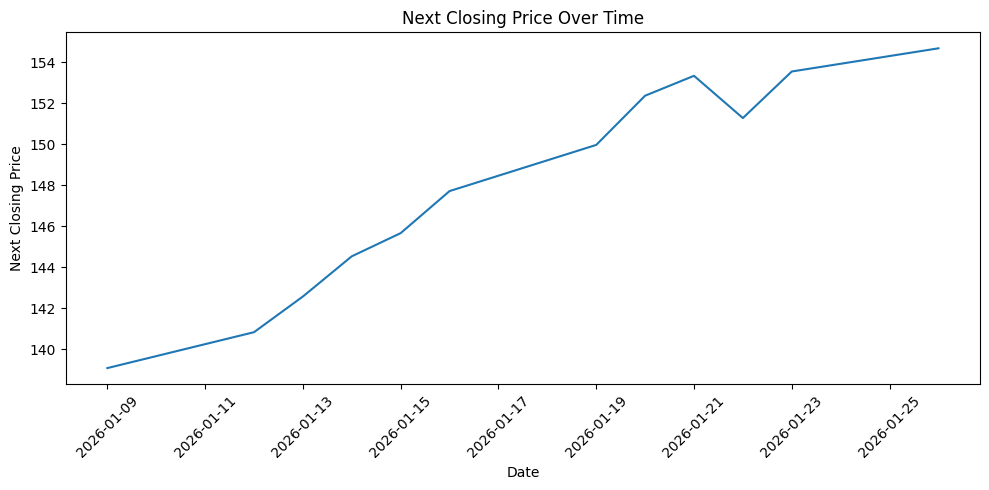

In [7]:
# Plot Next Closing Price over time

plt.figure(figsize=(10, 5))

plt.plot(
    df["Date"],
    df["Next_Close"]
)

plt.xlabel("Date")
plt.ylabel("Next Closing Price")
plt.title("Next Closing Price Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 3: Correlation Analysis

Correlation analysis is performed to study the relationship between
the predictors and the target variable, Next_Close.

In [10]:
# Calculate correlation matrix
corr = df.drop(columns=["Date"]).corr()

# Display correlation with Next_Close
print(corr["Next_Close"].sort_values(ascending=False))

Next_Close    1.000000
Close_Lag1    0.967235
MA5           0.961324
Close_Lag2    0.931979
Close_Lag3    0.902781
Volume_MA5    0.393130
Sentiment     0.121629
Volume       -0.370413
Name: Next_Close, dtype: float64


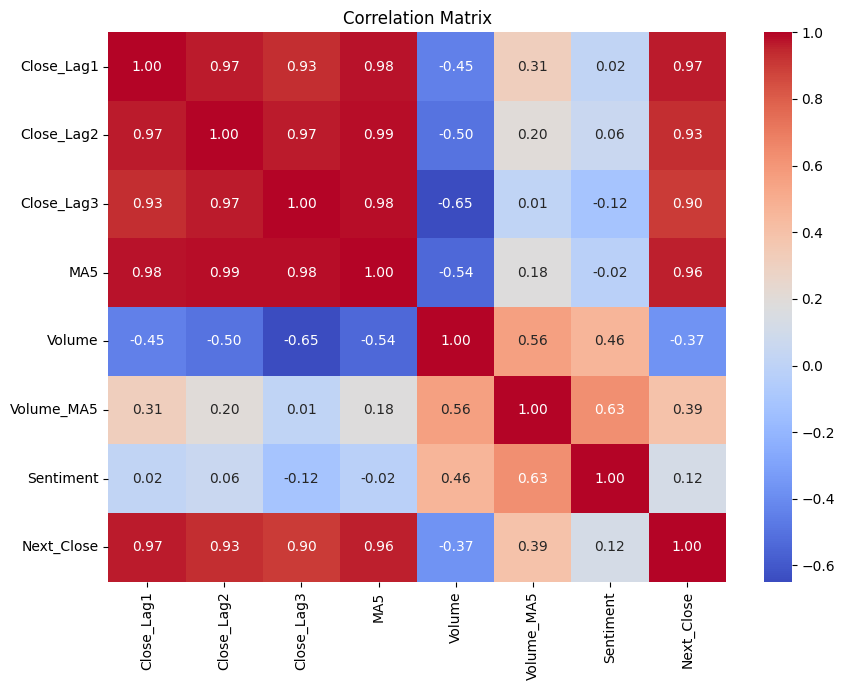

In [11]:
# Correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 4: Define X and y and Make a Chronological Split

The predictor variables are stored in X and the dependent variable
Next_Close is stored in y.

An 80% training and 20% testing split is performed chronologically.
Random shuffling is avoided because the dataset represents time-ordered
observations.

In [13]:
# Define predictor variables
features = [
    "Close_Lag1",
    "Close_Lag2",
    "Close_Lag3",
    "MA5",
    "Volume",
    "Volume_MA5",
    "Sentiment"
]

# Define X and y
X = df[features]
y = df["Next_Close"]

# 80% chronological split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = df["Date"].iloc[split_index:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 9
Testing observations: 3


## Step 5: Build the Multiple Linear Regression Model

A Multiple Linear Regression model is trained using the training data.
The intercept and coefficients of all predictors are displayed.

In [20]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display intercept
print("Intercept:", model.intercept_)

# Display coefficients
for feature, coefficient in zip(features, model.coef_):
    print(feature, ":", coefficient)

Intercept: -14.242970270024216
Close_Lag1 : -0.2634010019571443
Close_Lag2 : -0.6309807134571112
Close_Lag3 : -0.8218332553229094
MA5 : 2.6538544402535766
Volume : -4.609854531566204e-06
Volume_MA5 : 2.882140890980711e-05
Sentiment : 0.6765582328578209


## Step 6: Predict and Compare

The trained model is used to predict the Next_Close values for the
test dataset.

A comparison table containing the actual value, predicted value and
residual is created.

In [21]:
# Predict test data
y_pred = model.predict(X_test)

# Create comparison DataFrame
comparison = pd.DataFrame({
    "Date": dates_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": y_test.values - y_pred
})

print(comparison)

        Date  Actual   Predicted  Residual
0 2026-01-22  151.27  151.563651 -0.293651
1 2026-01-23  153.54  152.152948  1.387052
2 2026-01-26  154.67  153.520277  1.149723


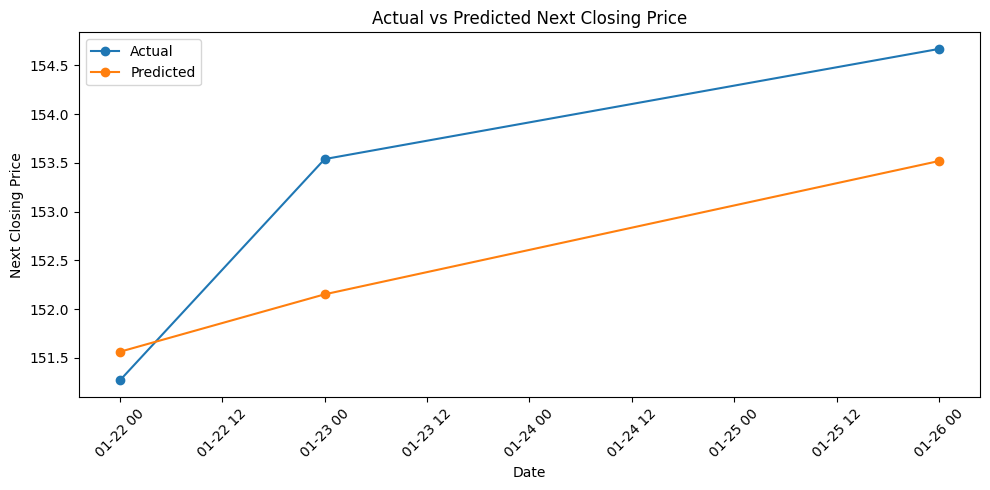

In [22]:
# Actual vs Predicted plot

plt.figure(figsize=(10, 5))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual",
    marker="o"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Next Closing Price")
plt.title("Actual vs Predicted Next Closing Price")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 7: Evaluate the Model and Naive Baseline

The model is evaluated using MAE, MSE, RMSE, R² and Adjusted R².

A naive baseline is also calculated by using Close_Lag1 as the prediction
for the next closing price.

In [23]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Number of observations and predictors
n, p = X_test.shape

# Adjusted R2
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Naive prediction
naive_pred = X_test["Close_Lag1"].to_numpy()

# Naive RMSE
naive_rmse = np.sqrt(
    mean_squared_error(y_test, naive_pred)
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)
print("Naive RMSE:", naive_rmse)

MAE: 0.9434750067624691
MSE: 1.1106685468466904
RMSE: 1.0538826058184518
R2: 0.4443508587299275
Adjusted R2: 1.222259656508029
Naive RMSE: 1.8862131374794238


In [24]:
# Training predictions
train_pred = model.predict(X_train)

# Training residuals
train_residuals = y_train.to_numpy() - train_pred

# Test fitted values
fitted_values = y_pred

# Test residuals
residuals = y_test.to_numpy() - y_pred

print("Training residual mean:", np.mean(train_residuals))
print("Test residual mean:", np.mean(residuals))

Training residual mean: -3.157967714489334e-15
Test residual mean: 0.7477079982791489


# Activity 2: Investigating Multiple Linear Regression Assumptions

## Assumption 1: Linearity

The linearity assumption is checked using a residuals versus fitted values
plot.

Randomly scattered residuals around zero support the linear form.

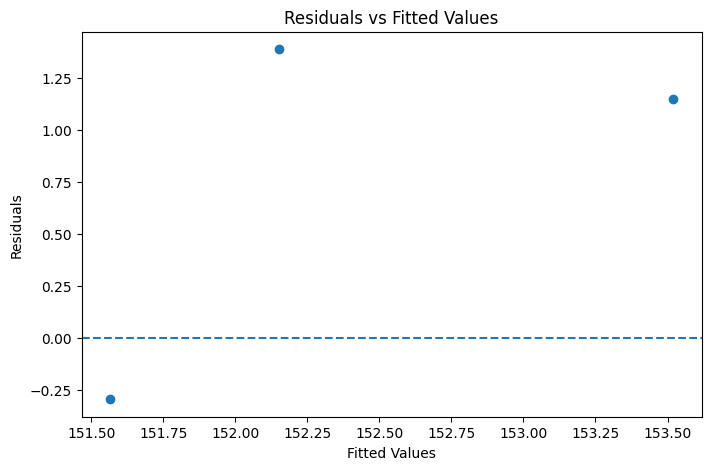

In [25]:
# Residuals vs Fitted Values

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

## Assumption 2: Independence of Errors

The residuals are plotted according to their observation order and the
Durbin-Watson statistic is calculated.

In [26]:
# Durbin-Watson statistic

dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

Durbin-Watson: 0.8646700591283807


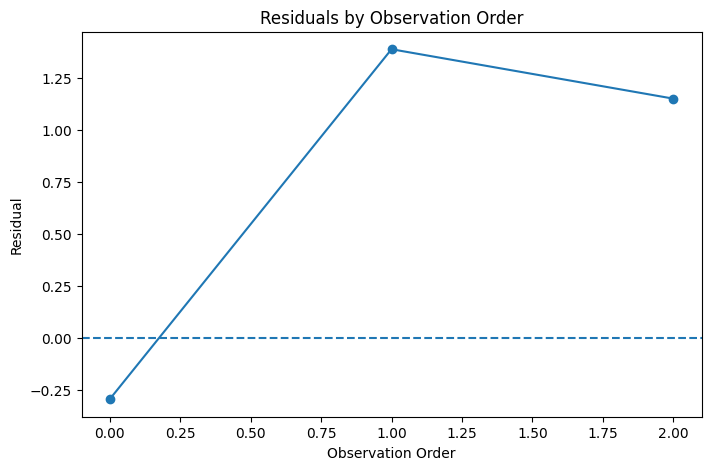

In [27]:
# Residuals by observation order

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(len(residuals)),
    residuals,
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Observation Order")
plt.ylabel("Residual")
plt.title("Residuals by Observation Order")

plt.show()

## Assumption 3: Homoscedasticity

Homoscedasticity is checked using a residual plot and the Breusch-Pagan
test.

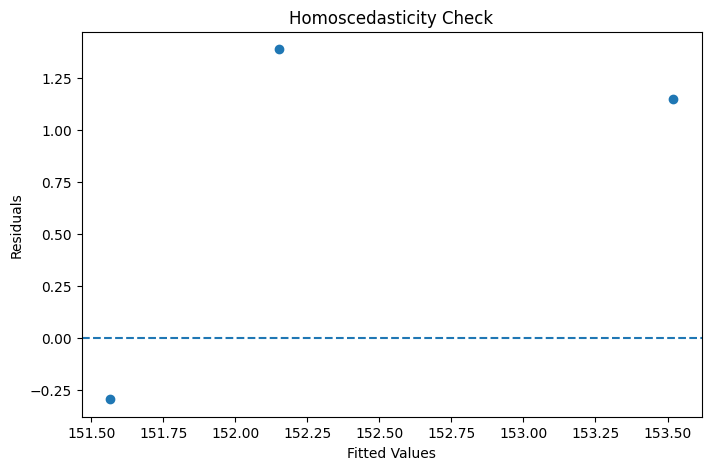

In [29]:
# Homoscedasticity plot

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")

plt.show()

In [30]:
# Breusch-Pagan test

X_bp = np.column_stack([
    np.ones(len(X_train)),
    X_train
])

bp = het_breuschpagan(
    train_residuals,
    X_bp
)

print("LM statistic:", bp[0])
print("LM p-value:", bp[1])
print("F statistic:", bp[2])
print("F p-value:", bp[3])

LM statistic: 1.2429519270504517
LM p-value: 0.989904081686172
F statistic: 0.022890738762650204
F p-value: 0.9996983739698792


## Assumption 4: Approximate Normality of Residuals

The distribution of residuals is examined using a histogram and a Q-Q plot.
The Shapiro-Wilk test is also calculated as supporting evidence.

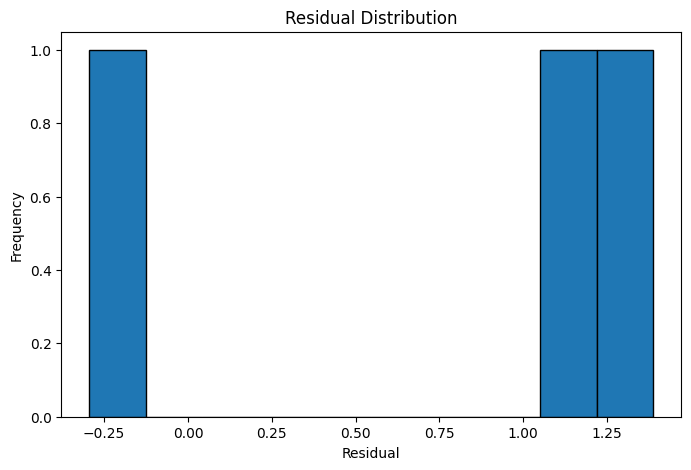

In [31]:
# Histogram of residuals

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

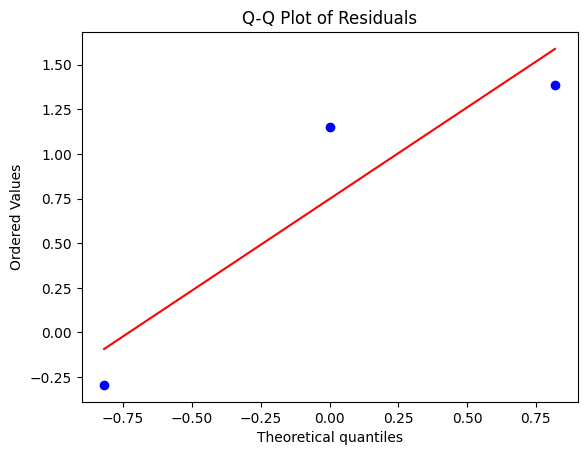

In [32]:
# Q-Q Plot

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.show()

In [34]:
# Shapiro-Wilk test

stat, p_value = shapiro(residuals)

print("Statistic:", stat)
print("p-value:", p_value)

Statistic: 0.8535030653155987
p-value: 0.2498640836662941


## Assumption 5: No Severe Multicollinearity

Variance Inflation Factor (VIF) is calculated to identify possible
multicollinearity among the predictor variables.

In [35]:
# Prepare training predictors
X_vif = X_train.astype(float)

# Calculate VIF
vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

      Feature            VIF
0  Close_Lag1  135422.456690
1  Close_Lag2  254175.004357
2  Close_Lag3  145128.934379
3         MA5  444887.038070
4      Volume     786.737359
5  Volume_MA5   13850.437721
6   Sentiment      10.808166


## Assumption 6: Outliers and Influential Observations

Standardized residuals are calculated to identify observations having
unusually large residuals.

Observations with an absolute standardized residual greater than 2 are
identified for investigation.

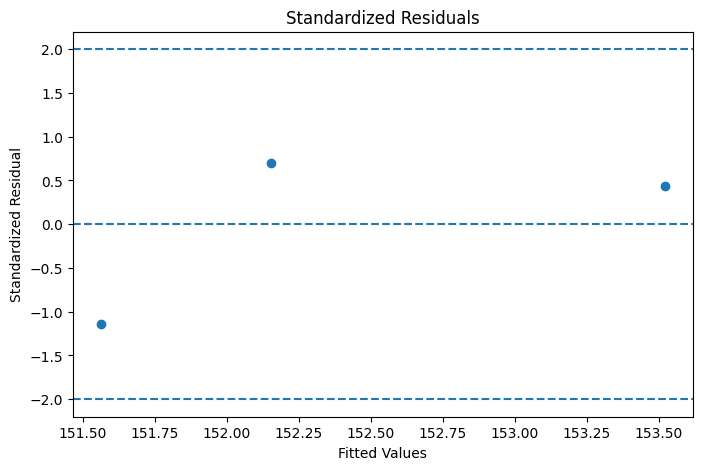

In [36]:
# Calculate standardized residuals

standardized_residuals = (
    residuals - np.mean(residuals)
) / np.std(residuals, ddof=1)

# Plot standardized residuals

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    standardized_residuals
)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals")

plt.show()

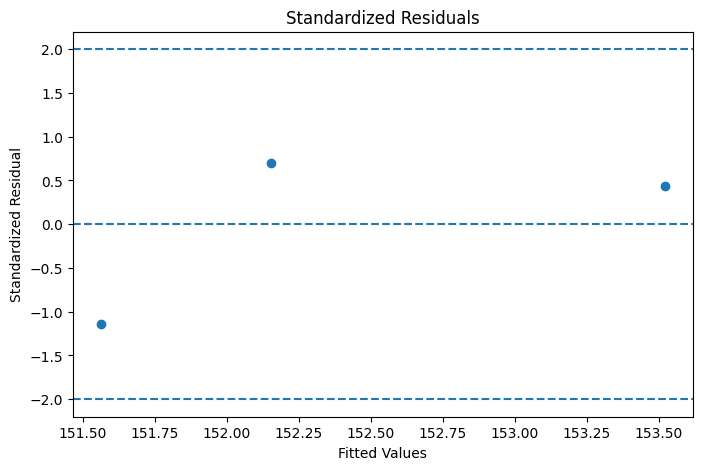

In [37]:
# Calculate standardized residuals

standardized_residuals = (
    residuals - np.mean(residuals)
) / np.std(residuals, ddof=1)

# Plot standardized residuals

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    standardized_residuals
)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals")

plt.show()

# Activity 3: Predict a New Observation

A new observation is created using the given values of the lagged prices,
moving average, volume and sentiment.

The trained MLR model is then used to predict the next closing price.

In [38]:
# Create new observation

new_day = pd.DataFrame({
    "Close_Lag1": [158.40],
    "Close_Lag2": [157.85],
    "Close_Lag3": [157.10],
    "MA5": [157.62],
    "Volume": [1025000],
    "Volume_MA5": [985000],
    "Sentiment": [0.25]
})

# Keep columns in the same order as training data
new_day = new_day[features]

# Predict next closing price
prediction = model.predict(new_day)

print("Predicted next closing price:", prediction[0])

Predicted next closing price: 157.45766430181794


# Activity 4: Model Improvement Challenge

## Improved Model

The original model contains three lagged closing-price variables.
Since these variables can be highly correlated, an alternative model is
created by removing Close_Lag2 and Close_Lag3.

The same chronological train-test split is maintained.

In [42]:
# Features for improved model

improved_features = [
    "Close_Lag1",
    "MA5",
    "Volume",
    "Volume_MA5",
    "Sentiment"
]

# Create improved X
X_improved = df[improved_features]

# Chronological split
X_train_improved = X_improved.iloc[:split_index]
X_test_improved = X_improved.iloc[split_index:]

# Create and train improved model
improved_model = LinearRegression()

improved_model.fit(
    X_train_improved,
    y_train
)

# Predict
improved_pred = improved_model.predict(
    X_test_improved
)

In [43]:
# Improved Model: Remove redundant lag variables

improved_features = [
    "Close_Lag1",
    "MA5",
    "Volume",
    "Volume_MA5",
    "Sentiment"
]

X_improved = df[improved_features]
y_improved = df["Next_Close"]

# Chronological 80/20 split
split_idx = int(len(df) * 0.8)

X_train_imp = X_improved.iloc[:split_idx]
X_test_imp = X_improved.iloc[split_idx:]

y_train_imp = y_improved.iloc[:split_idx]
y_test_imp = y_improved.iloc[split_idx:]

# Train improved model
improved_model = LinearRegression()
improved_model.fit(X_train_imp, y_train_imp)

# Prediction
y_pred_imp = improved_model.predict(X_test_imp)

# Metrics
improved_r2 = r2_score(y_test_imp, y_pred_imp)

n = len(y_test_imp)
p = X_test_imp.shape[1]

if n > p + 1:
    improved_adjusted_r2 = (
        1 - (1 - improved_r2) * (n - 1) / (n - p - 1)
    )
else:
    improved_adjusted_r2 = np.nan

improved_rmse = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))

print("Improved Model R²:", improved_r2)
print("Improved Model Adjusted R²:", improved_adjusted_r2)
print("Improved Model RMSE:", improved_rmse)

Improved Model R²: 0.07733394097686852
Improved Model Adjusted R²: nan
Improved Model RMSE: 1.3580450765147714


## Original vs Improved Model Comparison

In [44]:
# Compare original and improved models

model_comparison = pd.DataFrame({
    "Metric": [
        "R2",
        "Adjusted R2",
        "RMSE",
        "Naive RMSE"
    ],
    
    "Original Model": [
        r2,
        adjusted_r2,
        rmse,
        naive_rmse
    ],
    
    "Improved Model": [
        improved_r2,
        improved_adjusted_r2,
        improved_rmse,
        naive_rmse
    ]
})

print(model_comparison)

        Metric  Original Model  Improved Model
0           R2        0.444351        0.077334
1  Adjusted R2        1.222260             NaN
2         RMSE        1.053883        1.358045
3   Naive RMSE        1.886213        1.886213


# Final Assumption Checklist

The following diagnostics were performed:

- Linearity — Residual vs Fitted plot
- Independence — Residual order and Durbin-Watson
- Homoscedasticity — Residual plot and Breusch-Pagan test
- Residual Normality — Histogram, Q-Q plot and Shapiro-Wilk test
- Multicollinearity — Correlation matrix and VIF
- Outliers — Standardized residuals

The original and improved models are also compared using R², Adjusted R²,
RMSE and the naive baseline.